## Install PySpark and create a session

In [114]:
!pip install pyspark==4.1.2

In [115]:
from pyspark.sql import SparkSession
from pyspark.sql import DataFrameReader

#create a spark session
spark=SparkSession.builder.appName("AirQuality").getOrCreate()
spark

## Read in data to pyspark dataframe

In [116]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
#define folder path
path='/content/drive/MyDrive/AirQualityModel/SiteData'

#import datetime
from datetime import datetime,date,time

#Read a single CSV to check inferred schema
df=spark.read.csv('/content/drive/MyDrive/AirQualityModel/SiteData/AQ_Site1.csv',header=True,inferSchema=True)

In [118]:
#Check the top 5 rows to see that data has read in as expected
df.show(5)

+----------+--------+------------------------------------------+----------------+-----------------------+-------+-------------------+-------+--------------------+---------+---------+----------------+---------------+-------+
|      Date|    Time|PM2.5 particulate matter (Hourly measured)|         Status3|Modelled Wind Direction|Status5|Modelled Wind Speed|Status7|           Site Name| Latitude|Longitude|       Site Type|Local Authority|   Zone|
+----------+--------+------------------------------------------+----------------+-----------------------+-------+-------------------+-------+--------------------+---------+---------+----------------+---------------+-------+
|01/01/2025|01:00:00|                                     7.453|V ugm-3 (Ref.eq)|                  231.4|  N deg|               10.9| N ms-1|Borehamwood Meado...|51.661229| -0.27055|Urban Background|      Hertsmere|Eastern|
|01/01/2025|02:00:00|                                     4.151|V ugm-3 (Ref.eq)|                  231.9

In [119]:
#Check the schema
df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Time: string (nullable = true)
 |-- PM2.5 particulate matter (Hourly measured): string (nullable = true)
 |-- Status3: string (nullable = true)
 |-- Modelled Wind Direction: string (nullable = true)
 |-- Status5: string (nullable = true)
 |-- Modelled Wind Speed: string (nullable = true)
 |-- Status7: string (nullable = true)
 |-- Site Name: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Site Type: string (nullable = true)
 |-- Local Authority: string (nullable = true)
 |-- Zone: string (nullable = true)



#The inferred schema has mis-defined some fields as strings, when they should be dates, times floats and doubles

Define a new schema that better matches the expected data

In [120]:
from pyspark.sql.types import StructType, StructField, StringType, FloatType,DoubleType,TimestampType,DateType,TimeType

#define the schema
schema = StructType([
    StructField("Date", DateType(), nullable=True),
    StructField("Time", TimestampType(), nullable=True),
    StructField("ParticulateReading", DoubleType(), nullable=True),
    StructField("ParticulateStatus", StringType(),nullable=True),
    StructField("WindDirection",FloatType(), nullable=True),
    StructField("WindDirection Status",StringType(),nullable=True),
    StructField("WindSpeed",FloatType(),nullable=True),
    StructField("windSpeedStatus",StringType(),nullable=True),
    StructField("SiteName",StringType(),nullable=True),
    StructField("Latitude",DoubleType(),nullable=True),
    StructField("Longitude",DoubleType(),nullable=True),
    StructField("SiteType",StringType(),nullable=True),
    StructField("LocalAuthority",StringType(),nullable=True),
    StructField("Zone",StringType(),nullable=True)
    ])

#Read a single CSV to confirm that new schema has been applied
df2=spark.read.csv('/content/drive/MyDrive/AirQualityModel/SiteData/AQ_Site1.csv',header=True,schema=schema)
df2.printSchema()



root
 |-- Date: date (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- ParticulateReading: double (nullable = true)
 |-- ParticulateStatus: string (nullable = true)
 |-- WindDirection: float (nullable = true)
 |-- WindDirection Status: string (nullable = true)
 |-- WindSpeed: float (nullable = true)
 |-- windSpeedStatus: string (nullable = true)
 |-- SiteName: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- SiteType: string (nullable = true)
 |-- LocalAuthority: string (nullable = true)
 |-- Zone: string (nullable = true)



In [121]:
df2.show(5)

+----+-------------------+------------------+-----------------+-------------+--------------------+---------+---------------+--------------------+---------+---------+----------------+--------------+-------+
|Date|               Time|ParticulateReading|ParticulateStatus|WindDirection|WindDirection Status|WindSpeed|windSpeedStatus|            SiteName| Latitude|Longitude|        SiteType|LocalAuthority|   Zone|
+----+-------------------+------------------+-----------------+-------------+--------------------+---------+---------------+--------------------+---------+---------+----------------+--------------+-------+
|NULL|2026-07-18 01:00:00|             7.453| V ugm-3 (Ref.eq)|        231.4|               N deg|     10.9|         N ms-1|Borehamwood Meado...|51.661229| -0.27055|Urban Background|     Hertsmere|Eastern|
|NULL|2026-07-18 02:00:00|             4.151| V ugm-3 (Ref.eq)|        231.9|               N deg|     11.3|         N ms-1|Borehamwood Meado...|51.661229| -0.27055|Urban Backg

# Having confirmed the new schema is being applied on a single CSV, we now read all the CSVs together into a single dataframe

However, we can see that the data has returned as NULL, as it is not in the default format - when loading in the full dataset, we will use the dataFormat option to define the date format used

In [122]:
#read all csv files in folder to single dataframe
df=(spark.read
    .format('csv')
    .option('header',True)
    .option('dateFormat','dd/MM/yyyy')
    .option('timeFormat',"HH:mm:ss")
    .schema(schema)
    .load(path))
#Check the schema
df.printSchema()


root
 |-- Date: date (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- ParticulateReading: double (nullable = true)
 |-- ParticulateStatus: string (nullable = true)
 |-- WindDirection: float (nullable = true)
 |-- WindDirection Status: string (nullable = true)
 |-- WindSpeed: float (nullable = true)
 |-- windSpeedStatus: string (nullable = true)
 |-- SiteName: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- SiteType: string (nullable = true)
 |-- LocalAuthority: string (nullable = true)
 |-- Zone: string (nullable = true)



Defining the time field as a timestamp has caused an arbitary date to be added; As the data is hourly measurements, we will use the hour() function to add a column containing an integer representing the hour

In [123]:
#add required functions
import pyspark.sql.functions as sf
from pyspark.sql import Column
#Add "hour" column
df=df.withColumn('Hour',sf.hour(df.Time))
#re-cast Time to string format by removing the date element
df=df.withColumn('Time',sf.date_format(sf.col("Time"), "HH:mm:ss"))
#Check output
df.show(5)
df.printSchema()

+----------+--------+------------------+-----------------+-------------+--------------------+---------+---------------+--------------------+---------+---------+----------------+--------------+-------+----+
|      Date|    Time|ParticulateReading|ParticulateStatus|WindDirection|WindDirection Status|WindSpeed|windSpeedStatus|            SiteName| Latitude|Longitude|        SiteType|LocalAuthority|   Zone|Hour|
+----------+--------+------------------+-----------------+-------------+--------------------+---------+---------------+--------------------+---------+---------+----------------+--------------+-------+----+
|2025-01-01|01:00:00|            12.618| V ugm-3 (Ref.eq)|        236.5|               N deg|     13.7|         N ms-1|Peterborough Gart...|52.594012|-0.248945|Urban Background|  Peterborough|Eastern|   1|
|2025-01-01|02:00:00|             3.325| V ugm-3 (Ref.eq)|        236.0|               N deg|     14.2|         N ms-1|Peterborough Gart...|52.594012|-0.248945|Urban Background

# Initial Data Exploration and pre-processing

In [124]:
#Start with using the describe function on the core columns (non-status) to get a picture of the data
df.select("Date","ParticulateReading","WindDirection","WindSpeed","Hour").describe().show()

+-------+------------------+------------------+------------------+-----------------+
|summary|ParticulateReading|     WindDirection|         WindSpeed|             Hour|
+-------+------------------+------------------+------------------+-----------------+
|  count|             94814|             94512|             94512|           100740|
|   mean| 8.279079050540904|190.12797106147906| 4.985920306270009|             12.0|
| stddev| 7.585490844882654| 95.93799013619055|2.5476289647349706|6.633282503576391|
|    min|              -2.0|               0.0|               0.0|                1|
|    max|            79.151|             360.0|              21.7|               23|
+-------+------------------+------------------+------------------+-----------------+



There is a spread of values across the target variable (particulate reading); these will be plotted to look in more detail.

We will also examine the data for indications of correlation between the target variable and the others

In [125]:
#We also need to examine the categorical fields, specifically site type
df.groupBy(df.SiteType).count().show()

+----------------+-----+
|        SiteType|count|
+----------------+-----+
|            NULL|   48|
|   Urban Traffic|26280|
|Rural Background|35040|
|Urban Background|43800|
+----------------+-----+



We can see that there are 3 main site types; reasonaly distributed across all three, but with a slight skew towards 'Urban background'.  There is a small amount of null values; given the small number, these rows can be removed from the dataset

Comparing the total count by SiteType minus nulls (105,120) and the counts by numerical fields above, we can see that there is a reasonable amount of missing data (~10%).

In [126]:
#lets examine the data by site name
df.groupBy(df.SiteName).count().show()


+--------------------+-----+
|            SiteName|count|
+--------------------+-----+
|Borehamwood Meado...| 8760|
|                NULL|   48|
|      Barnstaple A39| 8760|
|Peterborough Gart...| 8760|
| Norwich Lakenfields| 8760|
|     Southend-on-Sea| 8760|
|          Wicken Fen| 8760|
|            Thurrock| 8760|
|              Sibton| 8760|
| Luton A505 Roadside| 8760|
|           Weybourne| 8760|
|      Sandy Roadside| 8760|
|            St Osyth| 8760|
+--------------------+-----+



There are the same number of null rows as with SiteType; these are likely the same rows so removing these records is probably the best way to handle the missing data in this case.

In [127]:
#we look at the numerical fields by site name and site type to see how the missing data is distributed.
import pandas as pd
import pyspark.pandas as ps
described = ps.DataFrame(df.select("SiteName","ParticulateReading","WindDirection","WindSpeed","Hour"))
described.groupby('SiteName').describe().sort_index()

ParticulateReading                                                            WindDirection                                                                              WindSpeed                                                       Hour                                            
                                     count       mean       std    min    25%     50%     75%     max         count        mean         std  min         25%         50%         75%         max     count      mean       std  min  25%  50%  75%        max   count  mean       std  min  25%   50%   75%   max
SiteName                                                                                                                                                                                                                                                                                                         
Barnstaple A39                      8609.0   7.199360  5.617355  0.283  3.585   5.590   8.962  67.076        8544.0  182.071489   86.790355  0.1  112.699997  173.699997  255.199997  360.000000    8544.0  4.933240  2.467065  0.0  3.1  4.6  6.5  16.299999  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Borehamwood Meadow Park             8647.0   8.213246  7.348208  0.283  3.774   5.755   9.811  66.510        8544.0  182.690836  100.799205  0.1   89.500000  206.600006  255.000000  359.700012    8544.0  3.971524  1.808608  0.0  2.7  3.6  5.0  12.700000  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Luton A505 Roadside                 8604.0   9.000980  7.624132  0.307  4.269   6.604  10.991  78.656        8544.0  192.195353   95.244523  0.1  117.400002  212.699997  262.799988  359.600006    8544.0  4.769089  2.262578  0.0  3.1  4.4  6.1  15.200000  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Norwich Lakenfields                 8563.0   7.934342  6.989364  0.519  3.703   5.542   9.434  62.571        8544.0  194.295330   96.587515  0.0  118.199997  214.500000  264.399994  360.000000    8544.0  4.468340  2.180971  0.0  2.9  4.1  5.7  15.500000  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Peterborough Garton End             8750.0   8.302518  7.784442  0.330  3.538   5.566   9.835  64.882        8544.0  193.991292   95.821781  0.0  118.400002  216.699997  260.899994  359.899994    8544.0  4.483193  2.176456  0.0  2.9  4.1  5.7  14.800000  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Sandy Roadside                       505.0  13.617822  9.465606 -2.000  6.000  12.000  20.000  50.000         528.0  227.123674   71.853953  0.2  198.899994  231.800003  271.299988  359.200012     528.0  3.854924  2.546243  0.5  2.1  3.2  4.7  14.100000  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Sibton                              8702.0   7.570853  7.367717  0.377  3.325   5.142   8.585  63.562        8544.0  197.074333   97.812392  0.1  112.900002  218.899994  269.700012  360.000000    8544.0  4.696067  2.241588  0.0  3.1  4.3  5.9  16.900000  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Southend-on-Sea                     8541.0   8.689885  8.037322  0.307  4.009   5.873  10.307  70.920        8544.0  187.292439   97.871523  0.1   99.300003  209.199997  260.299988  360.000000    8544.0  5.956929  2.771241  0.1  3.9  5.7  7.7  21.400000  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
St Osyth                            8754.0   8.405682  7.702916  0.354  3.939   5.873   9.646  64.623        8544.0  189.187640   97.550909  0.0   99.199997  208.699997  262.299988  359.899994    8544.0  6.533017  3.067655  0.3  4.3  6.1  8.5  21.700001  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Thurrock                            8751.0   9.036760  8.541364  0.377  4.057   6.038  10.660  79.151        8544.0  188.958310   96.924938  0.0  103.800003  208.399994  264.000000  360.000000    8544.0  4.088577  1.987831  0.0  2.7  3.7  5.2  14.300000  8395.0  12.0  6.633645  1.0  6.0  12.0  18.0  23.0
Weybourne                           8733.0   8

In [128]:
#provide a count by columns to demonstrate where missing vaules are
described.groupby('SiteName').count().sort_index()

,ParticulateReading,WindDirection,WindSpeed,Hour
SiteName,,,,
Barnstaple A39,8609,8544,8544,8395
Borehamwood Meadow Park,8647,8544,8544,8395
Luton A505 Roadside,8604,8544,8544,8395
Norwich Lakenfields,8563,8544,8544,8395
Peterborough Garton End,8750,8544,8544,8395
Sandy Roadside,505,528,528,8395
Sibton,8702,8544,8544,8395
Southend-on-Sea,8541,8544,8544,8395
St Osyth,8754,8544,8544,8395


In [129]:
#Look at site type by site name
df.groupBy('SiteName','SiteType').count().show()

+--------------------+----------------+-----+
|            SiteName|        SiteType|count|
+--------------------+----------------+-----+
|                NULL|            NULL|   48|
| Norwich Lakenfields|Urban Background| 8760|
|Peterborough Gart...|Urban Background| 8760|
|Borehamwood Meado...|Urban Background| 8760|
|      Barnstaple A39|   Urban Traffic| 8760|
|          Wicken Fen|Rural Background| 8760|
|     Southend-on-Sea|Urban Background| 8760|
|      Sandy Roadside|   Urban Traffic| 8760|
|            St Osyth|Rural Background| 8760|
|           Weybourne|Rural Background| 8760|
|            Thurrock|Urban Background| 8760|
|              Sibton|Rural Background| 8760|
| Luton A505 Roadside|   Urban Traffic| 8760|
+--------------------+----------------+-----+



In [130]:
#Average values by site type
df.groupBy('SiteType').avg().show()

+----------------+-----------------------+------------------+------------------+-----------------+-------------------+---------+
|        SiteType|avg(ParticulateReading)|avg(WindDirection)|    avg(WindSpeed)|    avg(Latitude)|     avg(Longitude)|avg(Hour)|
+----------------+-----------------------+------------------+------------------+-----------------+-------------------+---------+
|            NULL|                   NULL|              NULL|              NULL|             NULL|               NULL|     NULL|
|   Urban Traffic|      8.257180550852194|188.33203907704598| 4.821304495094072|  51.699834333343|-1.6014466666667215|     12.0|
|Rural Background|      8.088941762203019|191.90659527678181| 5.561031133439854| 52.3303159999867| 0.9813602499998204|     12.0|
|Urban Background|      8.436829073753763| 189.4456413951772|4.5937125464460085|51.97826000002274| 0.3558981999998343|     12.0|
+----------------+-----------------------+------------------+------------------+-----------------

In [131]:
#Average values by Site Name
df.groupBy('SiteName').avg().show()

+--------------------+-----------------------+------------------+------------------+------------------+--------------------+---------+
|            SiteName|avg(ParticulateReading)|avg(WindDirection)|    avg(WindSpeed)|     avg(Latitude)|      avg(Longitude)|avg(Hour)|
+--------------------+-----------------------+------------------+------------------+------------------+--------------------+---------+
|Borehamwood Meado...|       8.21324563432402|182.69083569121585|3.9715238750854693| 51.66122900000589|-0.27054999999999835|     12.0|
|                NULL|                   NULL|              NULL|              NULL|              NULL|                NULL|     NULL|
|      Barnstaple A39|      7.199360320594692|182.07148882701875| 4.933239700359009|51.074793000005975|  -4.041924000000113|     12.0|
|Peterborough Gart...|      8.302517839771435|193.99129212309245| 4.483192883916757| 52.59401200000346|-0.24894500000002223|     12.0|
| Norwich Lakenfields|       7.93434193623726| 194.2953

Sandy Roadside looks to have a substantial number of missing values.

The particulate reading average for the available data is higher than the other sites and for the other Urban Traffic sites, so imputing data to fill the missing values would likely skew the overall dataset.  In this case, it is preferable to remove the sandy roadside data from the overall dataset.

This will remove one of the Urban Traffic site types, but sufficient data will be retained (~17,000 records).

The missing hours are due to midnight in the data being represented as 24:00:00, which has not translated to a hour properly - these will be replaced with 0 in-line with standard time formatting.

The other missing values appear to be fairly evenly distributed across sites, these will be handled by imputting the mean value for each site. As the descriptive statistics suggest that the values are reasonably evenly grouped around the mean this should minimise skew while maximising retained data points.

We will also remove columns that are less relevent to the project (Time / Longitude / Latitude / Zone / LocalAuthority and Status columns)

In [132]:
#Create subset of relevent data, ignoring columns to be removed
df_tidy=df.select('Date','SiteName','SiteType','ParticulateReading','WindSpeed','WindDirection','Hour')
#Check that new dataframe fits expectations
df_tidy.show(5)

+----------+--------------------+----------------+------------------+---------+-------------+----+
|      Date|            SiteName|        SiteType|ParticulateReading|WindSpeed|WindDirection|Hour|
+----------+--------------------+----------------+------------------+---------+-------------+----+
|2025-01-01|Peterborough Gart...|Urban Background|            12.618|     13.7|        236.5|   1|
|2025-01-01|Peterborough Gart...|Urban Background|             3.325|     14.2|        236.0|   2|
|2025-01-01|Peterborough Gart...|Urban Background|             2.453|     14.2|        235.9|   3|
|2025-01-01|Peterborough Gart...|Urban Background|             1.934|     12.7|        235.9|   4|
|2025-01-01|Peterborough Gart...|Urban Background|             1.722|     12.6|        234.9|   5|
+----------+--------------------+----------------+------------------+---------+-------------+----+
only showing top 5 rows


In [133]:
#remove rows relating to Sandy Roadside and null
df_tidy=df_tidy.dropna(subset=['SiteName'])
df_tidy=df_tidy.filter(df_tidy.SiteName!='Sandy Roadside')
#Check output is as expected
df_tidy.groupBy('SiteName').count().show()

+--------------------+-----+
|            SiteName|count|
+--------------------+-----+
|Borehamwood Meado...| 8760|
|      Barnstaple A39| 8760|
|Peterborough Gart...| 8760|
| Norwich Lakenfields| 8760|
|     Southend-on-Sea| 8760|
|          Wicken Fen| 8760|
|            Thurrock| 8760|
|              Sibton| 8760|
| Luton A505 Roadside| 8760|
|           Weybourne| 8760|
|            St Osyth| 8760|
+--------------------+-----+



In [134]:
#generate baseline before fixing hours value
df_tidy.select('Hour').groupBy('Hour').count().show(24)

+----+-----+
|Hour|count|
+----+-----+
|  12| 4015|
|  22| 4015|
|NULL| 4015|
|   1| 4015|
|  13| 4015|
|   6| 4015|
|  16| 4015|
|   3| 4015|
|  20| 4015|
|   5| 4015|
|  19| 4015|
|  15| 4015|
|   9| 4015|
|  17| 4015|
|   4| 4015|
|   8| 4015|
|  23| 4015|
|   7| 4015|
|  10| 4015|
|  21| 4015|
|  11| 4015|
|  14| 4015|
|   2| 4015|
|  18| 4015|
+----+-----+



In [135]:
#replace null hour values with 0
df_tidy=df_tidy.na.fill({'Hour':0})
#check changes in place
df_tidy.select('Hour').groupBy('Hour').count().show(24)


+----+-----+
|Hour|count|
+----+-----+
|  12| 4015|
|  22| 4015|
|   1| 4015|
|  13| 4015|
|   6| 4015|
|  16| 4015|
|   3| 4015|
|  20| 4015|
|   5| 4015|
|  19| 4015|
|  15| 4015|
|   9| 4015|
|  17| 4015|
|   4| 4015|
|   8| 4015|
|  23| 4015|
|   7| 4015|
|  10| 4015|
|  21| 4015|
|  11| 4015|
|  14| 4015|
|   2| 4015|
|   0| 4015|
|  18| 4015|
+----+-----+



In [136]:
#replace null ParticulateReading with site average for each value
#create a sub-table of average values by site name
#define as a function
from pyspark.sql import Column as pc

cols = [df_tidy.ParticulateReading,df_tidy.WindSpeed,df_tidy.WindDirection]

for col in cols:
  PrAvg = df_tidy.select(df_tidy.SiteName,col).groupby('SiteName').avg()
  PrAvg = PrAvg.withColumnRenamed(PrAvg.columns[1],'SiteAvg')
  #PrAvg.show()
  #Use join to add the average value to the main table
  df_tidy=df_tidy.join(PrAvg,on='SiteName',how='left')
  #Use when statement to replace null values
  df_tidy=df_tidy.withColumn('imputed', sf.ifnull(col,df_tidy.SiteAvg))
  #remove unwanted columns and rename imputed as ParticulateReading
  colName = str(col)[8:-2]
  df_tidy = df_tidy.drop('SiteAvg',colName)
  df_tidy=df_tidy.withColumnRenamed('imputed',colName)

df_tidy.show(5)



+--------------------+----------+----------------+----+------------------+------------------+------------------+
|            SiteName|      Date|        SiteType|Hour|ParticulateReading|         WindSpeed|     WindDirection|
+--------------------+----------+----------------+----+------------------+------------------+------------------+
|Peterborough Gart...|2025-01-01|Urban Background|   1|            12.618|13.699999809265137|             236.5|
|Peterborough Gart...|2025-01-01|Urban Background|   2|             3.325|14.199999809265137|             236.0|
|Peterborough Gart...|2025-01-01|Urban Background|   3|             2.453|14.199999809265137|235.89999389648438|
|Peterborough Gart...|2025-01-01|Urban Background|   4|             1.934|12.699999809265137|235.89999389648438|
|Peterborough Gart...|2025-01-01|Urban Background|   5|             1.722|12.600000381469727|234.89999389648438|
+--------------------+----------+----------------+----+------------------+------------------+---

In [137]:
#Check the counts
chck = ps.DataFrame(df_tidy)
chck.groupby('SiteName').count().sort_index()

,Date,SiteType,Hour,ParticulateReading,WindSpeed,WindDirection
SiteName,,,,,,
Barnstaple A39,8760,8760,8760,8760,8760,8760
Borehamwood Meadow Park,8760,8760,8760,8760,8760,8760
Luton A505 Roadside,8760,8760,8760,8760,8760,8760
Norwich Lakenfields,8760,8760,8760,8760,8760,8760
Peterborough Garton End,8760,8760,8760,8760,8760,8760
Sibton,8760,8760,8760,8760,8760,8760
Southend-on-Sea,8760,8760,8760,8760,8760,8760
St Osyth,8760,8760,8760,8760,8760,8760
Thurrock,8760,8760,8760,8760,8760,8760


In [138]:
#Use info to confirm that all nulls have been filled
chck.info()

<class 'pyspark.pandas.frame.DataFrame'>
Index: 96360 entries, 0 to 96359
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SiteName            96360 non-null  object 
 1   Date                96360 non-null  object 
 2   SiteType            96360 non-null  object 
 3   Hour                96360 non-null  int32  
 4   ParticulateReading  96360 non-null  float64
 5   WindSpeed           96360 non-null  float64
 6   WindDirection       96360 non-null  float64
dtypes: float64(3), int32(1), object(3)

Text(0.5, 1.0, 'Count of measurements by site type')

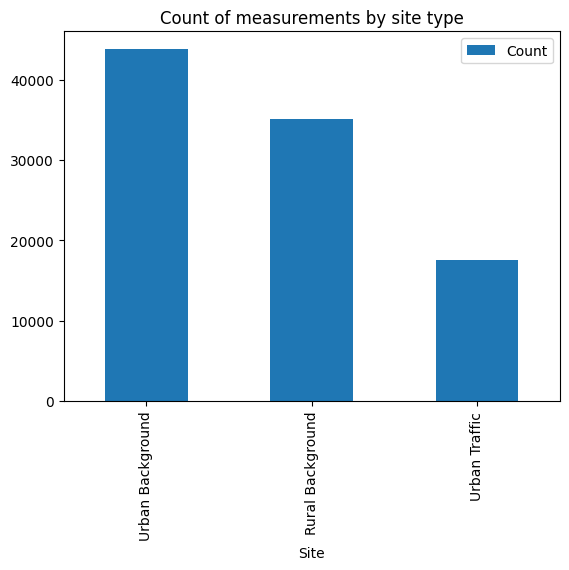

In [139]:
#Initial exploration charts to examine distributions before creating test splits
import matplotlib.pyplot as plt
import seaborn as sns
#Lets start by looking site type
#create two lists - site type and associated count
site = [x[0] for x in df_tidy.groupBy('SiteType').count().collect()]
cnt = [x[1] for x in df_tidy.groupBy('SiteType').count().collect()]
#combine into dataframe
site=pd.DataFrame({'Site':site, 'Count':cnt})
site.head()
#plot as bar chart
site.sort_values('Count',ascending=False).plot(kind='bar',x='Site',y='Count')
plt.xlabel='Site Type'
plt.ylabel='Count of measurements'
plt.title('Count of measurements by site type')


We can see that the We can see that the distibution is not even between site types, with urban traffic sites noticably lower than other types.  Next lets look at the impact of site type on average air quality

Text(0.5, 1.0, 'Average particulate level by site type')

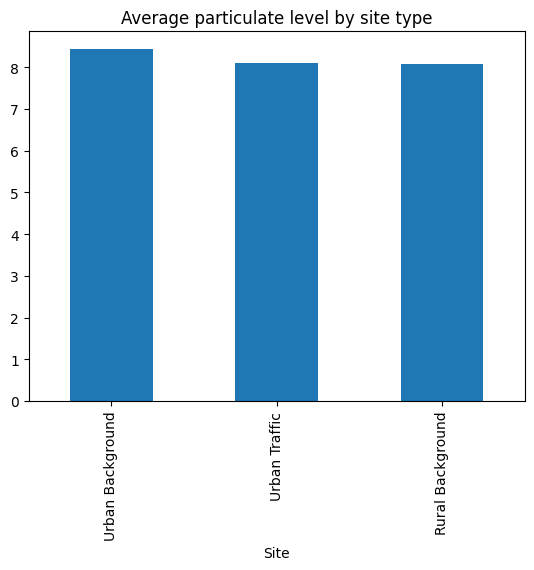

In [140]:
site_AQ = df_tidy.select('SiteType','ParticulateReading')
site = [x[0] for x in site_AQ.groupBy('SiteType').avg().collect()]
avg = [x[1] for x in site_AQ.groupBy('SiteType').avg().collect()]
#combine into dataframe
site=pd.DataFrame({'Site':site, 'Average':avg})
site.head()
#plot as bar chart
site.sort_values('Average',ascending=False).plot(kind='bar',x='Site',y='Average',legend=False)
plt.xlabel='Site Type'
plt.ylabel='Average Particulate Level'
plt.title('Average particulate level by site type')

We can see that there is only a small variance between site types, however the average particulate level is slightly higher in urban background and urban traffic types

Text(0.5, 1.0, 'Average particulate level by time')

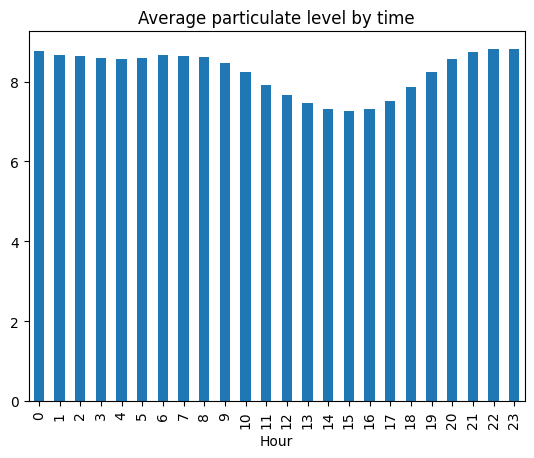

In [141]:
#Extract relevent data
Hour_AQ = df_tidy.select('Hour','ParticulateReading')
hr = [x[0] for x in Hour_AQ.groupBy('Hour').avg('ParticulateReading').collect()]
avg= [x[1] for x in Hour_AQ.groupBy('Hour').avg('ParticulateReading').collect()]
#Place into a pandas dataframe
hours = pd.DataFrame({'Hour':hr, 'Average':avg})
#plot as bar chart
hours.sort_values('Hour',ascending=True).plot(kind='bar',x='Hour',y='Average',legend=False)
plt.xlabel='Time (Hour)'
plt.ylabel='Average Particulate Level'
plt.title('Average particulate level by time')

We can see a pattern by hour, suggesting that this may be a potential predictor.  We will need to pay attention to the distribution of records by hour in both test and train; which should be close to even across all hours

Finally, we will look at the distribution of the target variable to check the distribution and identify outliers

Text(0.5, 1.0, 'Particulate reading distribution')

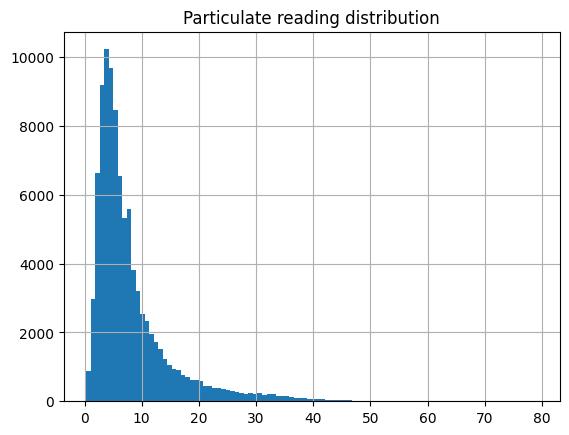

In [142]:
#extract to dataframe
aq=df_tidy.select('ParticulateReading')
pr = [x[0] for x in aq.collect()]
pr=pd.DataFrame({'ParticulateLevel':pr})

pr.hist(bins=100)
plt.xlabel='Particulate Reading'
plt.ylabel='Count of Instances'
plt.title('Particulate reading distribution')

We can see that the majority or readings fall between 0 and 10, with a reasonable number falling between 25 and 40, with a few as high as 80.

In [143]:
described = ps.DataFrame(df_tidy.select('SiteName','ParticulateReading'))
described.groupby('SiteName').describe().sort_index()

ParticulateReading                                                         
                                     count      mean       std    min    25%    50%     75%     max
SiteName                                                                                           
Barnstaple A39                      8760.0  7.199360  5.568724  0.283  3.609  5.660   8.892  67.076
Borehamwood Meadow Park             8760.0  8.213246  7.300655  0.283  3.774  5.849   9.811  66.510
Luton A505 Roadside                 8760.0  9.000980  7.555933  0.307  4.292  6.722  10.849  78.656
Norwich Lakenfields                 8760.0  7.934342  6.910317  0.519  3.750  5.637   9.245  62.571
Peterborough Garton End             8760.0  8.302518  7.779997  0.330  3.538  5.590   9.835  64.882
Sibton                              8760.0  7.570853  7.343283  0.377  3.349  5.165   8.538  63.562
Southend-on-Sea                     8760.0  8.689885  7.936208  0.307  4.057  5.967  10.047  70.920
St Osyth                            8760.0  8.405682  7.700278  0.354  3.939  5.873   9.646  64.623
Thurrock                            8760.0  9.036760  8.536974  0.377  4.057  6.038  10.660  79.151
Weybourne                           8760.0  8.330958  7.460912  0.401  3.774  5.991  10.283  63.279
Wicken Fen                          8760.0  8.039580  7.650713  0.354  3.467  5.778   8.302  69.835

We can see that the mean, stadard deviation and IQR are similar across all sites, with no significant outliers


# Create test and train datasets, ensuring that splits are suitably stratified

We will use random split to define our test and training samples; however as we want to retain the same distribution of site types in both datasets we will divide the data frame into each site type, split and recombine the test and train samples together.

We will use an 85%/15% split, as the large amount of data means 15% will be more than enough to test with

In [144]:
#create sub-lists on Urban Background, Rural Background and Urban Traffic

df_UB=df_tidy.filter(df_tidy.SiteType=='Urban Background')
df_RB=df_tidy.filter(df_tidy.SiteType=='Rural Background')
df_UT=df_tidy.filter(df_tidy.SiteType=='Urban Traffic')

#Split into train and test using reandom split
ubTrain,ubTest = df_UB.randomSplit(weights=[0.85,0.15],seed=42)
rbTrain,rbTest = df_RB.randomSplit(weights=[0.85,0.15],seed=42)
utTrain,utTest = df_UT.randomSplit(weights=[0.85,0.15],seed=42)

#recombine into overall test and train
df_train=ubTrain.union(rbTrain).union(utTrain)
df_test=ubTest.union(rbTest).union(utTest)

#count rows to check split
print(df_tidy.count())
print(df_train.count())
print(df_test.count())

96360
82078
14282


# Explore training dataset

In [145]:
#create a sample of 5% the training dataset as a pandas dataframe to minimise processing load
rb_sample = rbTrain.sample(fraction=0.05,seed=42)
ub_sample = ubTrain.sample(fraction=0.05,seed=42)
ut_sample = utTrain.sample(fraction=0.05,seed=42)

#combine into single sample
df_explore = rb_sample.union(ub_sample).union(ut_sample)


<Axes: xlabel='Date', ylabel='Average'>

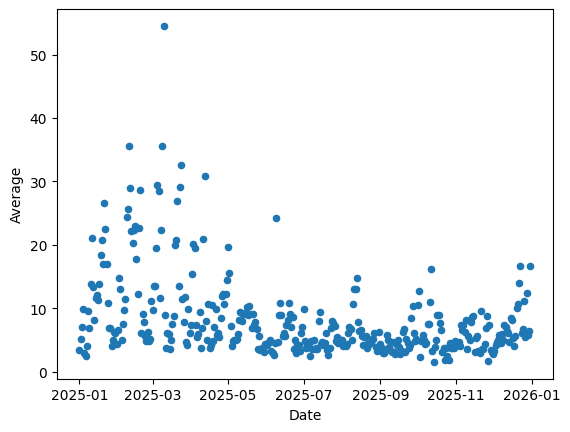

In [146]:
#plot target variable by date
date=[x[0] for x in df_explore.groupBy('Date').avg('ParticulateReading').collect()]
avg=[x[1] for x in df_explore.groupBy('Date').avg('ParticulateReading').collect()]
date=pd.DataFrame({'Date':date, 'Average':avg})
date.sort_values('Date',ascending=True).plot(kind='scatter',x='Date',y='Average',legend=False)

A scatter by date shows a lot of variation.  At the date level of granularity it is difficult to see a pattern - lets look at the same data by day of week and month

+----------+----------+----------------+----+------------------+------------------+------------------+---------+
|  SiteName|      Date|        SiteType|Hour|ParticulateReading|         WindSpeed|     WindDirection|DayOfWeek|
+----------+----------+----------------+----+------------------+------------------+------------------+---------+
|Wicken Fen|2025-01-01|Rural Background|  18|             2.099| 7.099999904632568|             269.0|      Wed|
|Wicken Fen|2025-01-04|Rural Background|  19|            12.925|3.9000000953674316|145.10000610351562|      Sat|
|Wicken Fen|2025-01-05|Rural Background|   7|             1.675| 8.300000190734863|140.89999389648438|      Sun|
|Wicken Fen|2025-01-06|Rural Background|   0|              2.83| 5.300000190734863|262.70001220703125|      Mon|
|Wicken Fen|2025-01-06|Rural Background|   4|             2.547|              12.0|204.39999389648438|      Mon|
+----------+----------+----------------+----+------------------+------------------+-------------

<Axes: title={'center': 'Air Quality'}, xlabel='Day'>

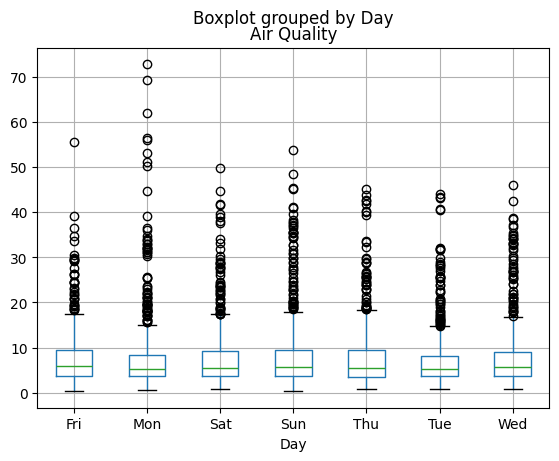

In [147]:
# use dayname function to convert Date into the day of the week
from pyspark.sql.functions import dayname
df_explore=df_explore.withColumn('DayOfWeek',dayname(df_explore.Date))
df_explore.show(5)

#now plot this as a scatter plot
day = [x[0] for x in df_explore.select('DayOfWeek','ParticulateReading').collect()]
aq = [x[1] for x in df_explore.select('DayOfWeek','ParticulateReading').collect()]
day=pd.DataFrame({'Day':day, 'Air Quality':aq})
day.sort_values('Day',ascending=True).boxplot(column='Air Quality',by='Day')

We can see variation by day, particularly in terms of peak levels; we will add this as a feature when developing the pipleline.

Lets also look at the variation by month


+----------+----------+----------------+----+------------------+------------------+------------------+---------+-----+
|  SiteName|      Date|        SiteType|Hour|ParticulateReading|         WindSpeed|     WindDirection|DayOfWeek|Month|
+----------+----------+----------------+----+------------------+------------------+------------------+---------+-----+
|Wicken Fen|2025-01-01|Rural Background|  18|             2.099| 7.099999904632568|             269.0|      Wed|    1|
|Wicken Fen|2025-01-04|Rural Background|  19|            12.925|3.9000000953674316|145.10000610351562|      Sat|    1|
|Wicken Fen|2025-01-05|Rural Background|   7|             1.675| 8.300000190734863|140.89999389648438|      Sun|    1|
|Wicken Fen|2025-01-06|Rural Background|   0|              2.83| 5.300000190734863|262.70001220703125|      Mon|    1|
|Wicken Fen|2025-01-06|Rural Background|   4|             2.547|              12.0|204.39999389648438|      Mon|    1|
+----------+----------+----------------+----+---

<Axes: title={'center': 'Air Quality'}, xlabel='Month'>

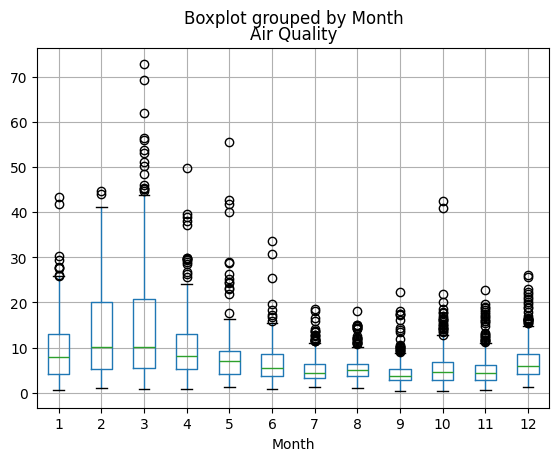

In [148]:
from pyspark.sql.functions import month
df_explore=df_explore.withColumn('Month',month(df_explore.Date))
df_explore.show(5)

mnth = [x[0] for x in df_explore.select('Month','ParticulateReading').collect()]
aq = [x[1] for x in df_explore.select('Month','ParticulateReading').collect()]
month=pd.DataFrame({'Month':mnth, 'Air Quality':aq})
month.sort_values('Month',ascending=True).boxplot(column='Air Quality',by='Month')


We also see strong variation by month; we will add both day of week and month to the datasets



In [149]:
from pyspark.sql.functions import monthname, dayname
df_tidy=df_tidy.withColumn('Month',monthname(df_tidy.Date))
df_tidy=df_tidy.withColumn('DayOfWeek',dayname(df_tidy.Date))
df_tidy.show(5)

+--------------------+----------+----------------+----+------------------+------------------+------------------+-----+---------+
|            SiteName|      Date|        SiteType|Hour|ParticulateReading|         WindSpeed|     WindDirection|Month|DayOfWeek|
+--------------------+----------+----------------+----+------------------+------------------+------------------+-----+---------+
|Peterborough Gart...|2025-01-01|Urban Background|   1|            12.618|13.699999809265137|             236.5|  Jan|      Wed|
|Peterborough Gart...|2025-01-01|Urban Background|   2|             3.325|14.199999809265137|             236.0|  Jan|      Wed|
|Peterborough Gart...|2025-01-01|Urban Background|   3|             2.453|14.199999809265137|235.89999389648438|  Jan|      Wed|
|Peterborough Gart...|2025-01-01|Urban Background|   4|             1.934|12.699999809265137|235.89999389648438|  Jan|      Wed|
|Peterborough Gart...|2025-01-01|Urban Background|   5|             1.722|12.600000381469727|234.

In [150]:
#Save the processed data as a parquet file
df_tidy.write.parquet("/content/drive/MyDrive/AirQualityModel/processed.pq", mode="overwrite")

#check by reading the data back in
read_in=spark.read.parquet("/content/drive/MyDrive/AirQualityModel/processed.pq")
read_in.show(5)

+--------------------+----------+----------------+----+------------------+------------------+------------------+-----+---------+
|            SiteName|      Date|        SiteType|Hour|ParticulateReading|         WindSpeed|     WindDirection|Month|DayOfWeek|
+--------------------+----------+----------------+----+------------------+------------------+------------------+-----+---------+
|Peterborough Gart...|2025-01-01|Urban Background|   1|            12.618|13.699999809265137|             236.5|  Jan|      Wed|
|Peterborough Gart...|2025-01-01|Urban Background|   2|             3.325|14.199999809265137|             236.0|  Jan|      Wed|
|Peterborough Gart...|2025-01-01|Urban Background|   3|             2.453|14.199999809265137|235.89999389648438|  Jan|      Wed|
|Peterborough Gart...|2025-01-01|Urban Background|   4|             1.934|12.699999809265137|235.89999389648438|  Jan|      Wed|
|Peterborough Gart...|2025-01-01|Urban Background|   5|             1.722|12.600000381469727|234.

# Combine all steps to